# Q-Learning with Table 🤖 🎛 🍽 🚕
> This is an exercise of Q-learning at its simplest for solving Reinforcement Learning (RL) problems. The challenge here is a "Taxi-V3" that is being solved via **table** approach for Q-learning implementation.

## A small recap of Q-Learning

- The *Q-Learning* **is the RL algorithm that**  

  - Trains *Q-Function*, an **action-value function** that contains, as internal memory, a *Q-table* **that contains all the state-action pair values.**
    
  - Given a state and action, our Q-Function **will search into its Q-table the corresponding value.**

  - When the training is done,**we have an optimal Q-Function, so an optimal Q-Table.**
    
  - And if we **have an optimal Q-function**, we
have an optimal policy,since we **know for each state, what is the best action to take.**

This is the Q-Learning pseudocode:

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit3/Q-learning-2.jpg" alt="Q-Learning" width="100%"/>


# Let's code our Q-Learning with Table 🚀

## Install dependencies and create a virtual display 🔽

In [22]:
!pip install -r https://raw.githubusercontent.com/huggingface/deep-rl-class/main/notebooks/unit2/requirements-unit2.txt

  Using cached pickle5-0.0.11.tar.gz (132 kB)
  Preparing metadata (setup.py) ... done
  Using cached PyYAML-6.0.tar.gz (124 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [78 lines of output]
      /private/var/folders/yh/wdfg42fn3q14n27yd20290nh0000gn/T/pip-build-env-l90tscuc/overlay/lib/python3.13/site-packages/setuptools/dist.py:759: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: MIT License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              *************

In [23]:
!sudo apt-get update
!sudo apt-get install -y python3-opengl
!apt install ffmpeg xvfb
!pip3 install pyvirtualdisplay

sudo: apt-get: command not found
sudo: apt-get: command not found
/bin/bash: apt: command not found


# this is the mac commands

In [ ]:
# macOS: install XQuartz (X11 server) and required Python packages
# Install XQuartz using Homebrew cask (or download from https://www.xquartz.org/)
!brew update && brew install --cask xquartz || true
# Install Python graphics/audio/ffmpeg backends via pip
!pip install PyOpenGL PyOpenGL_accelerate imageio imageio-ffmpeg pyvirtualdisplay pyglet || true
# Note: After installing XQuartz, you may need to log out/login or restart your session for X11 to be available.

==> Updating Homebrew...
Already up-to-date.


: 

Now that we have installed the required libraries, we can set up our virtual display for rendering. Make sure XQuartz is running on your macOS system before proceeding.

In [ ]:
# Instead of force killing the kernel, we'll just make sure our display is properly configured
import os
os.kill(os.getpid(), 9)  # Force kill the current process to reset the environment
#os.environ['DISPLAY'] = ':0'  # Configure display for XQuartz

: 

In [1]:
# Virtual display
from pyvirtualdisplay import Display

virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

## Import the packages 📦

In [2]:
import numpy as np
import gymnasium as gym
import random
import imageio
import os
import tqdm
import matplotlib.pyplot as plt

import pickle
from tqdm.notebook import tqdm

# Environment: Taxi-v3 🚖

## Create and understand [Taxi-v3 🚕](https://www.gymlibrary.dev/environments/toy_text/taxi/)
---

💡 A good habit when you start to use an environment is to check its documentation

👉 https://www.gymlibrary.dev/environments/toy_text/taxi/

---

In `Taxi-v3` 🚕, there are four designated locations in the grid world indicated by R(ed), G(reen), Y(ellow), and B(lue).

When the episode starts, **the taxi starts off at a random square** and the passenger is at a random location. The taxi drives to the passenger’s location, **picks up the passenger**, drives to the passenger’s destination (another one of the four specified locations), and then **drops off the passenger**. Once the passenger is dropped off, the episode ends.


<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/notebooks/unit2/taxi.png" alt="Taxi">


In [25]:
#env = gym.make("Taxi-v3")
env = gym.make("Taxi-v3" , render_mode="rgb_array")

## Define the hyperparameters ⚙️
The exploration related hyperparamters are some of the most important ones.

- We need to make sure that our agent **explores enough of the state space** to learn a good value approximation. To do that, we need to have progressive decay of the epsilon.
- If you decrease epsilon too fast (too high decay_rate), **you take the risk that your agent will be stuck**, since your agent didn't explore enough of the state space and hence can't solve the problem.

In [24]:
# Training parameters
n_training_episodes = 25000   # Total training episodes
learning_rate = 0.7           # Learning rate

# Evaluation parameters
n_eval_episodes = 100        # Total number of test episodes

# DO NOT MODIFY EVAL_SEED
eval_seed = [16,54,165,177,191,191,120,80,149,178,48,38,6,125,174,73,50,172,100,148,146,6,25,40,68,148,49,167,9,97,164,176,61,7,54,55,
 161,131,184,51,170,12,120,113,95,126,51,98,36,135,54,82,45,95,89,59,95,124,9,113,58,85,51,134,121,169,105,21,30,11,50,65,12,43,82,145,152,97,106,55,31,85,38,
 112,102,168,123,97,21,83,158,26,80,63,5,81,32,11,28,148] # Evaluation seed, this ensures that all classmates agents are trained on the same taxi starting position
                                                          # Each seed has a specific starting state

# Environment parameters
max_steps = 99               # Max steps per episode
gamma = 0.95                 # Discounting rate

# Exploration parameters
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.05           # Minimum exploration probability
decay_rate = 0.005            # Exponential decay rate for exploration prob

# Q1: Let's see what the Environment looks like (10 pts)

---

---



In [22]:
print("_____OBSERVATION SPACE_____ \n")
print("Observation Space", env.observation_space)
print("Sample observation", env.observation_space.sample()) # Get a random observation

_____OBSERVATION SPACE_____ 

Observation Space Discrete(500)
Sample observation 229


In [23]:
print("_____ACTION SPACE_____ \n")
print("Action Space", env.action_space)
print("Sample observation", env.action_space.sample()) # Get a random observation

_____ACTION SPACE_____ 

Action Space Discrete(6)
Sample observation 2


Reward function 💰:

- -1 per step unless other reward is triggered.
- +20 delivering passenger.
- -10 executing “pickup” and “drop-off” actions illegally.

## Q1.1 Why the observation space shape is 500? (5 pts)

---



## Write Down Your Answer Here:
The taxi's position: The taxi can be in any cell of a 5x5 grid → 25 possible positions
Passenger's location: There are 5 possible locations (4 designated locations R, G, Y, B, and being inside the taxi) → 5 possibilities
Destination location: There are 4 possible destinations (R, G, Y, B) → 4 possibilities
Therefore, the total number of possible states is:
25 (taxi positions) × 5 (passenger locations) × 4 (destinations) = 500 states

## Q1.2 What are the possible actions the agent can take? (5 pts)

---



## Write Down Your Answer Here:

Move South (down)
Move North (up)
Move East (right)
Move West (left)
Pickup passenger
Drop off passenger
This is represented as Discrete(6) in the action space, meaning the agent can choose from these 6 discrete actions at each step. The rewards associated with these actions are:

Normal movement actions (south, north, east, west): -1 per step
Successfully delivering a passenger: +20
Illegally executing pickup or drop-off actions: -10

# Q2: Create and Initialize the Q-table (10 pts)
(👀 Step 1 of the pseudocode)

---



---



In [7]:
state_space = 500
action_space = 6


### Q2.1: Fill in function `initialize_q_table` below (10 pts)


In [8]:
def initialize_q_table(state_space, action_space):
  Qtable = np.zeros((state_space, action_space))
  return Qtable

In [9]:
Qtable_taxi = initialize_q_table(state_space, action_space)

# Q3: Define the epsilon-greedy policy (20 pts)

(👀 Step 2 of the pseudocode)

---



---




### Q3.1: Fill in function `epsilon_greedy_policy` below (20 pts)

In [26]:
def greedy_policy(Qtable, state):
    # Ensure state is an integer
    state_idx = state if isinstance(state, int) else state[0]
    # Exploitation: take the action with the highest state, action value
    action = np.argmax(Qtable[state_idx])
    return action

def epsilon_greedy_policy(Qtable, state, epsilon):
    # Randomly generate a number between 0 and 1
    random_num = random.uniform(0, 1)
    # if random_num > greater than epsilon --> exploitation
    if random_num > epsilon:
        # Take the action with the highest value given a state
        action = greedy_policy(Qtable, state)
    # else --> exploration
    else:
        action = env.action_space.sample()  # Take a random action
    
    return action

# Q4: Create the training loop method (40 pts)

The training loop goes like this:

```
For episode in the total of training episodes:

Reduce epsilon (since we need less and less exploration)
Reset the environment

  For step in max timesteps:    
    Choose the action At using epsilon greedy policy
    Take the action (a) and observe the outcome state(s') and reward (r)
    Update the Q-value Q(s,a) using Bellman equation Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    If done, finish the episode
    Our next state is the new state
```

---



---




## Q4.1: Fill in function `train` below (25 pts)

---



In [27]:
def train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable):
    # store the training progress of this algorithm for each episode
    episode_steps = []
    episode_resolveds = []

    for episode in tqdm(range(n_training_episodes)):
        # Reduce epsilon (because we need less and less exploration)
        epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)
        # Reset the environment
        state, _ = env.reset()  # Get initial state
        done = False

        # repeat
        for step in range(max_steps):
            # Choose the action At using epsilon greedy policy
            action = epsilon_greedy_policy(Qtable, state, epsilon)

            # Take action At and observe Rt+1 and St+1
            # Take the action (a) and observe the outcome state(s') and reward (r)
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
            Qtable[state][action] = Qtable[state][action] + learning_rate * \
                (reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])

            # If done, finish the episode
            if done:
                # -> store the collected rewards & number of steps in this episode
                episode_steps.append(step)
                episode_resolveds.append(1)
                step = 0
                break

            # Our next state is the new state
            state = new_state

        if step != 0:
            # -> store the collected rewards & number of steps in this episode
            episode_steps.append(step)
            episode_resolveds.append(0)
            step = 0

    return Qtable, episode_steps, episode_resolveds

### Train the Q-Learning agent


In [28]:
Qtable_taxi, episode_steps, episode_resolveds = train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable_taxi)

  0%|          | 0/25000 [00:00<?, ?it/s]

### Training Progress

In the generated graph, you will see red dots and a gree curve.

Red dots indicate how many steps to take to reach the goal at different eposides.

Green curve indicate whether the task is solved or not at different eposides.

If Q-learning is trained properly, you will observe it is more likely this task can be solved with the increase of training time.

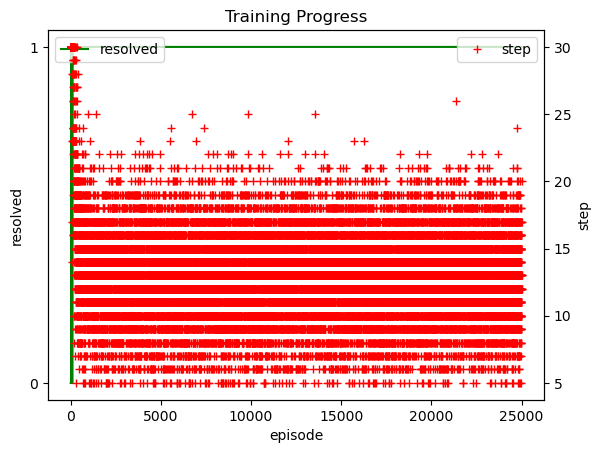

In [29]:
# plot the rewards and number of steps over all training episodes
fig = plt.figure()
ax1 = fig.add_subplot(111)
# ax1.plot(np.clip(episode_rewards, -30, 20), '-g', label = 'reward')
# ax1.set_yticks([-10,20])
ax1.plot(episode_resolveds, '-g', label = 'resolved')
ax1.set_yticks([0,1])
ax2 = ax1.twinx()
ax2.plot(np.clip(episode_steps, 0, 30), '+r', label = 'step')
ax1.set_xlabel("episode")
ax1.set_ylabel("resolved")
ax2.set_ylabel("step")
ax1.legend(loc=2)
ax2.legend(loc=1)
plt.title("Training Progress")
plt.show()

## Q4.2: What can you learn from the training progress above? (15 pts)

---



### Write Down Your Answer Here

The green resolved line becomes 1 very early and stays there.

This means:
The agent learned how to consistently complete the Taxi task very early in training within the first few thousand episodes.

The red crosses (step) stabilize around 10–20 steps per episode.

The step count no longer decreases — suggesting:

The agent has found a stable but not necessarily optimal policy.

This happens often in Taxi-v3 when ε (exploration rate) decays too quickly or the learning rate becomes too small.

Since performance doesn’t drop or fluctuate, the Q-table likely captures all key state-action pairs.The environment is deterministic enough that exploration gaps don’t harm final policy stability.

# Q5: Evaluation (20 pts)

- We defined the evaluation method that we're going to use to test our Q-Learning agent.

In [14]:
def evaluate_agent(env, max_steps, n_eval_episodes, Q, seed):
    """
    Evaluate the agent for ``n_eval_episodes`` episodes and returns average reward and std of reward.
    :param env: The evaluation environment
    :param n_eval_episodes: Number of episode to evaluate the agent
    :param Q: The Q-table
    :param seed: The evaluation seed array (for taxi-v3)
    """
    episode_rewards = []
    episode_penalties = []
    for episode in tqdm(range(n_eval_episodes)):
        if seed:
            state, _ = env.reset(seed=seed[episode])  # Get initial state
        else:
            state, _ = env.reset()  # Get initial state
        step = 0
        done = False
        total_rewards_ep = 0
        total_penalties_ep = 0

        for step in range(max_steps):
            # Take the action (index) that have the maximum expected future reward given that state
            action = greedy_policy(Q, state)
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_rewards_ep += reward

            if reward == -10:
                total_penalties_ep += 1

            if done:
                break
            state = new_state

        episode_rewards.append(total_rewards_ep)
        episode_penalties.append(total_penalties_ep)

    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)
    mean_penalty = np.mean(episode_penalties)
    std_penalty = np.std(episode_penalties)

    return mean_reward, std_reward, mean_penalty, std_penalty

## Evaluate our Q-Learning agent

In [15]:
# Evaluate our Agent
mean_reward, std_reward, mean_penalty, std_penalty = evaluate_agent(env, max_steps, n_eval_episodes, Qtable_taxi, eval_seed)
print(f"Mean_reward={mean_reward:.2f} +/- {std_reward:.2f}")
print(f"Mean_penalty={mean_penalty:.2f} +/- {std_penalty:.2f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Mean_reward=7.54 +/- 2.74
Mean_penalty=0.00 +/- 0.00


## Q5.1: What can you learn from the evaluation results above? (15 pts)

---


### Write Down Your Answer Here

A mean reward of +7.54 indicates that:

The agent usually succeeds but still takes multiple steps (each step costs -1).

Since the max reward is around +20 for an optimal policy, this score shows that:

It solves the task correctly, but

It takes longer than necessary, reducing the net total reward.

Moderate reward variance (±2.74)

There’s some variation across episodes — meaning:

The number of steps to success varies slightly.

The agent’s performance is stable but not perfectly consistent yet (it may take a few more or fewer steps depending on the initial state).



## Q5.2: Record Agent (5 pts)

---


#### Do not modify this code

In [16]:
def record_video(env, Qtable, out_directory, fps=1):
  """
  Generate a replay video of the agent
  :param env
  :param Qtable: Qtable of our agent
  :param out_directory
  :param fps: how many frame per seconds (with taxi-v3 and frozenlake-v1 we use 1)
  """
  images = []
  done = False
  state = env.reset(seed=100)
  img = env.render(mode='rgb_array')
  images.append(img)
  while not done:
    # Take the action (index) that have the maximum expected future reward given that state
    action = np.argmax(Qtable[state][:])
    state, reward, done, info = env.step(action) # We directly put next_state = state for recording logic
    img = env.render(mode='rgb_array')
    images.append(img)
  imageio.mimsave(out_directory, [np.array(img) for i, img in enumerate(images)], fps=fps)

In [18]:
def record_video(env, Qtable, out_directory, fps=1):
    """
    Generate a replay video of the agent
    :param env: Gymnasium environment
    :param Qtable: Qtable of our agent
    :param out_directory: Path to save the video
    :param fps: Frames per second
    """
    images = []
    done = False
    state, _ = env.reset(seed=100)  # Updated reset call
    img = env.render()  # Updated render call
    images.append(img)
    
    while not done:
        action = np.argmax(Qtable[state][:])
        state, reward, terminated, truncated, _ = env.step(action)  # Updated step call
        done = terminated or truncated
        img = env.render()  # Updated render call
        images.append(img)
        
    imageio.mimsave(out_directory, [np.array(img) for img in images], fps=fps)

In [19]:
record_video(env, Qtable_taxi, './replay.mp4')

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (550, 350) to (560, 352) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


**Your taxi should successfully pick up and drop off passenger in your recorded video.**

<video controls src="replay.mp4" width="500" height="340">